In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results, plot_loss, load_plot, load_plot_all_runs

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Increase font sizes for better visibility
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

In [2]:
loader = ResultLoader("../results")
experiments = {
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),
    "FedPLN": ("fedpln", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "har": 0, "fixed_proto": 0, "init_emb": 0}),
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 1.0}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1}),

    "FedPer": ("fedper", {}),
    "FedRep": ("fedrep", {"epochs_head": 5}),
    "FedProto": ("fedproto", {"mu": 1.0}),
    "FedALA": ("fedala", {"eta": 1.0, "rand_percent": 20, "layer_idx": 1, "ala_threshold": 0.1, "num_pre_loss": 10}),
    "FedTGP": ("fedtgp", {"lamda_": 10.0, "server_epochs": 10, "server_lr": 0.01, "margin_threshold": 1.0}),
    "FedDPC": ("feddpc", {"lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01, "lambda_p": 1.0, "lambda_acl": 0.01}),
    "LG-FedAvg": ("lgfedavg", {}),
    "FedKD": ("fedkd", {"lr_g": 0.01, "energy": 0.9}),
    "FML": ("fml", {"alpha_fml": 1.0, "beta_fml": 1.0}),
    "ProxyFL": ("proxyfl", {"mu": 1.0, "adj_type": "ring"}),
    "FedSA": ("fedsa", {"alpha_sa": 0.9999, "lambda_r": 0.1, "lambda_mcl": 0.01, "lambda_cc": 1.0}),
    "Local": ("local", {}),
}
global_algos = ["FedAvg", "FedProx", "Scaffold", "FedDyn", "FedPLN", "FedProc", "FedFM", "MOON", "FedLSA"]
personalized_algos = ["FedPer", "FedRep", "FedProto", "FedALA", "FedTGP", "FedDPC", "LG-FedAvg", "FedKD", "FML", "ProxyFL", "FedSA", "Local"]

In [3]:
loader.algo_patterns["feddpc"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}_{args['lambda_p']}_{args['lambda_acl']}"

common_args = {"dataset": "cifar10", "partition": "dirichlet", "num_clients": 10, "epochs": 1, "batch_size": 64, "lr": 0.01, "alpha": 0.1, "n_class": 5, "times": 5}

experiments["FedDPC"] = ("feddpc", {"epochs": 1, "lamda_": 100.0, "lambda_p": 1.0, "lambda_acl": 0.01, "head_epochs": 10, "body_epochs": 1, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})

In [4]:
# print("--- Personalized Algorithms Stats ---")
# load_plot_all_runs(personalized_algos, experiments, common_args, loader, x_lim=200)
# # load_plot_all_runs(['FedDPC'], experiments, common_args, loader, x_lim=200)

Figure saved to figures/split_test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
--------------------------------------------------------------------------------
Algorithm            |    Model Max | Model Last10 |    Proto Max | Proto Last10
--------------------------------------------------------------------------------
FedTGP               |      85.0711 |      84.7281 |      85.1985 |      83.5306
FedProto             |      84.5445 |      84.2058 |      83.5835 |      83.1253
FedDPC               |      86.2370 |      85.7024 |      86.2151 |      85.8489
--------------------------------------------------------------------------------


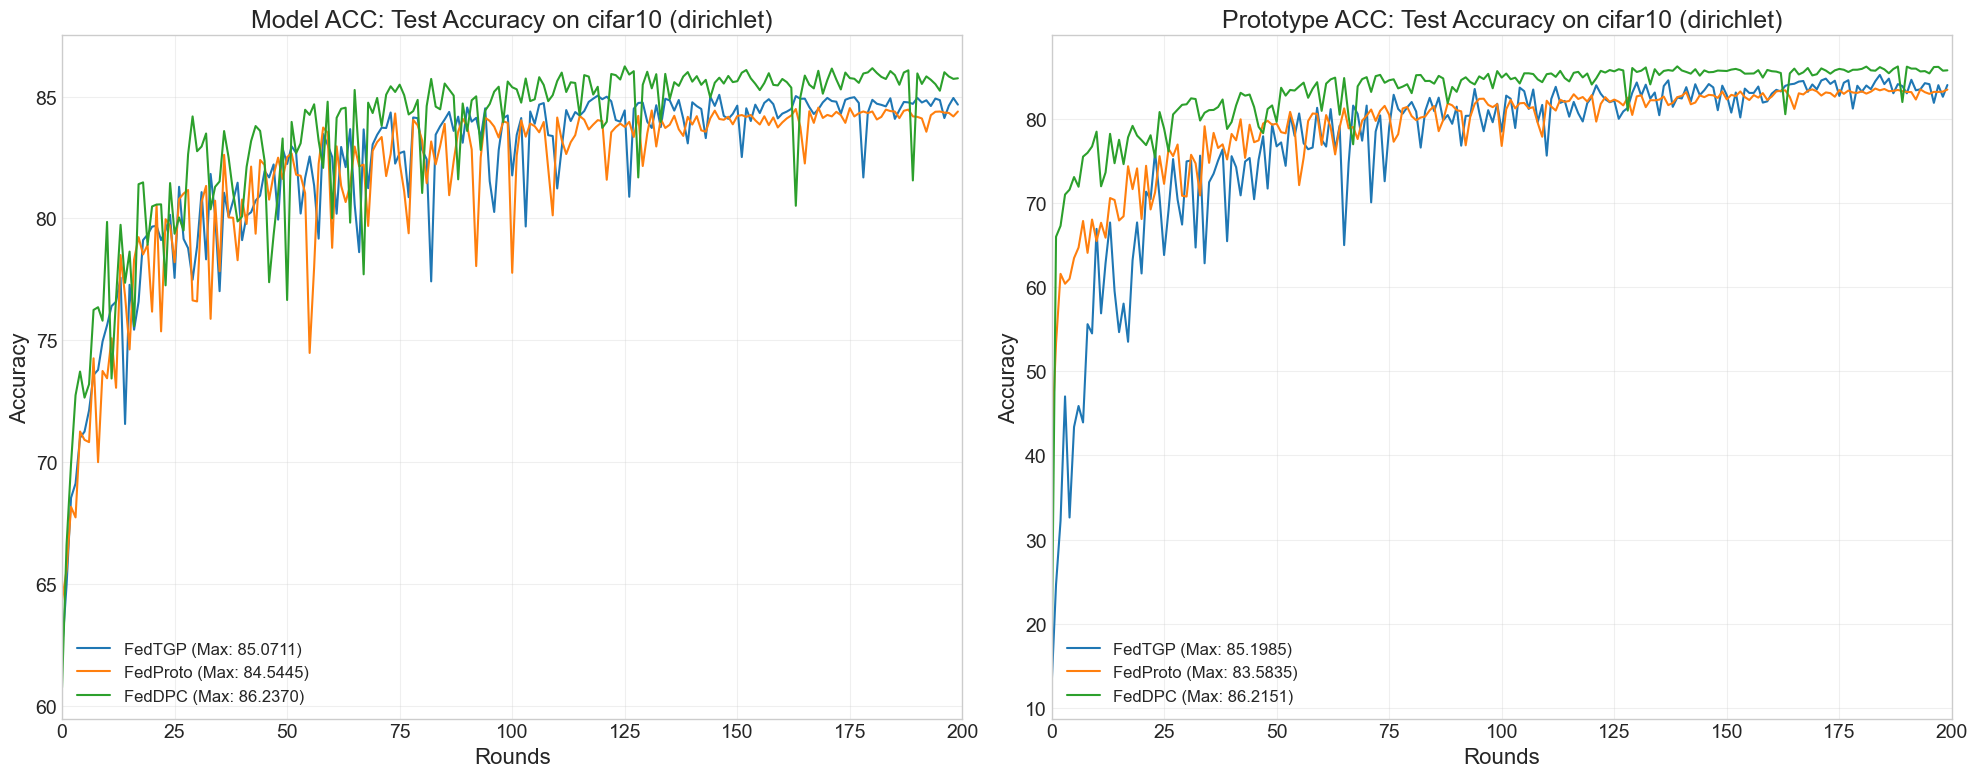

In [5]:
selected_group = personalized_algos.copy()
for algo in ['FedALA', 'FedPer', 'FedRep']:
    if algo in selected_group:
        selected_group.remove(algo)

selected_group = ['FedTGP', 'FedProto']
selected_group.extend(['FedDPC'])

load_plot(selected_group, experiments, common_args, loader, 200)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Summary of ACC:
--------------------------------------------------------------------------------
Algorithm            |    Model Max | Model Last10 |    Proto Max | Proto Last10
--------------------------------------------------------------------------------
FedDPC               |      86.2370 |      85.7024 |      86.2151 |      85.8489
FedProto             |      84.5445 |      84.2058 |      83.5835 |      83.1253
FedTGP               |      85.0711 |      84.7281 |      85.1985 |      83.5306
--------------------------------------------------------------------------------
Figure saved to figures/model_acc_sampled_cifar10.eps


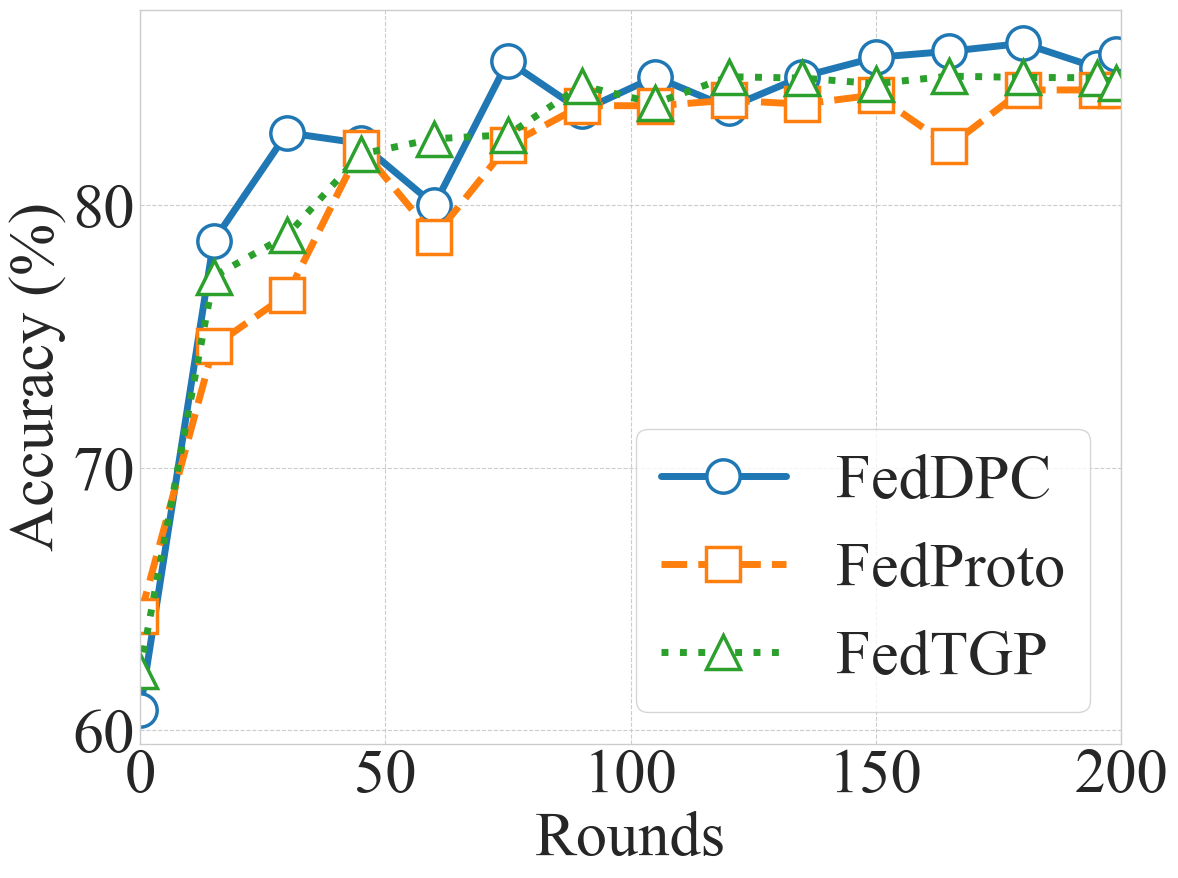

In [27]:
from utils import beautify_label, print_summary_table
import os
import numpy as np

TITLE_FONT_SIZE = 32
LABEL_FONT_SIZE = 45
TICK_FONT_SIZE = 45
LEGEND_FONT_SIZE = 45
chart_color = "#2c7fb8" # 深蓝色

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 20,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

selected_group = ['FedDPC', 'FedProto', 'FedTGP']
x_lim = 200

# Load data
results = {}
for label in selected_group:
    if label not in experiments: continue
    algo_name, kwargs = experiments[label]
    data = loader.load(algo_name, **{**common_args, **kwargs}, specific_run=0)
    if data: results[label] = data

if results:
    # Print summary table
    print_summary_table(results, x_lim)

    # Plot results: Only Model Accuracy
    fig, ax = plt.subplots(figsize=(12, 9))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'X']
    linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 10))]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, (label, data) in enumerate(results.items()):
        acc_data = data.get('acc')
        if acc_data is None: continue

        display_label = beautify_label(label)
        marker = markers[i % len(markers)]
        linestyle = linestyles[i % len(linestyles)]
        color = colors[i % len(colors)]

        plot_kwargs = {
            'marker': marker,
            'markersize': 24,
            'markerfacecolor': 'white',
            'markeredgewidth': 2.5,
            'linewidth': 5,
            'linestyle': linestyle,
            'color': color
        }

        # Get Model Accuracy Data
        y_full = None
        if isinstance(acc_data, dict):
            mk = next((k for k in ["model", "local"] if k in acc_data), None)
            if mk: y_full = acc_data[mk]
        elif isinstance(acc_data, list):
            y_full = acc_data

        if y_full is not None:
            y_valid = y_full[:x_lim]
            x_sampled = np.arange(len(y_valid))[::INTERVAL]
            if (len(y_valid)-1) % INTERVAL != 0:
                x_sampled = np.append(x_sampled, len(y_valid)-1)
            y_sampled = [y_valid[int(idx)] for idx in x_sampled]

            ax.plot(x_sampled, y_sampled, label=display_label, **plot_kwargs)

    ax.set_xlabel("Rounds", fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel("Accuracy (%)", fontsize=LABEL_FONT_SIZE)
    ax.legend(fontsize=TICK_FONT_SIZE, frameon=True, loc='lower right')
    ax.grid(True, linestyle='--', alpha=1.0)
    ax.set_xlim(0, x_lim)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)

    plt.tight_layout()

    # Save as EPS
    os.makedirs("figures", exist_ok=True)
    out_path = f"figures/model_acc_sampled_{common_args['dataset']}.eps"
    plt.savefig(out_path, format='eps', bbox_inches='tight')
    print(f"Figure saved to {out_path}")

    plt.show()
else:
    print("No results found.")